In [2]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import nrrd
import trimesh
import IONData
from turtle import rt
import numpy as np
import matplotlib
from PIL import Image
from scipy.ndimage import binary_dilation
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

In [4]:

iondata = IONData.IONData()
res,path = iondata.getStructureMask(262)
rtstructureMask,header = nrrd.read(path)
part1mesh = trimesh.load('../resource/rt/262_part_1.1.obj')
part2mesh = trimesh.load('../resource/rt/262_part_2.1.obj')

print(part1mesh.vertices)

[[7088.73 4201.35 2847.6 ]
 [7089.83 4193.6  2848.33]
 [7092.34 4205.65 2848.49]
 ...
 [5933.79 5033.28 5092.03]
 [5924.73 5024.71 5092.95]
 [5928.58 5029.03 5094.54]]


(1320, 800, 1140)


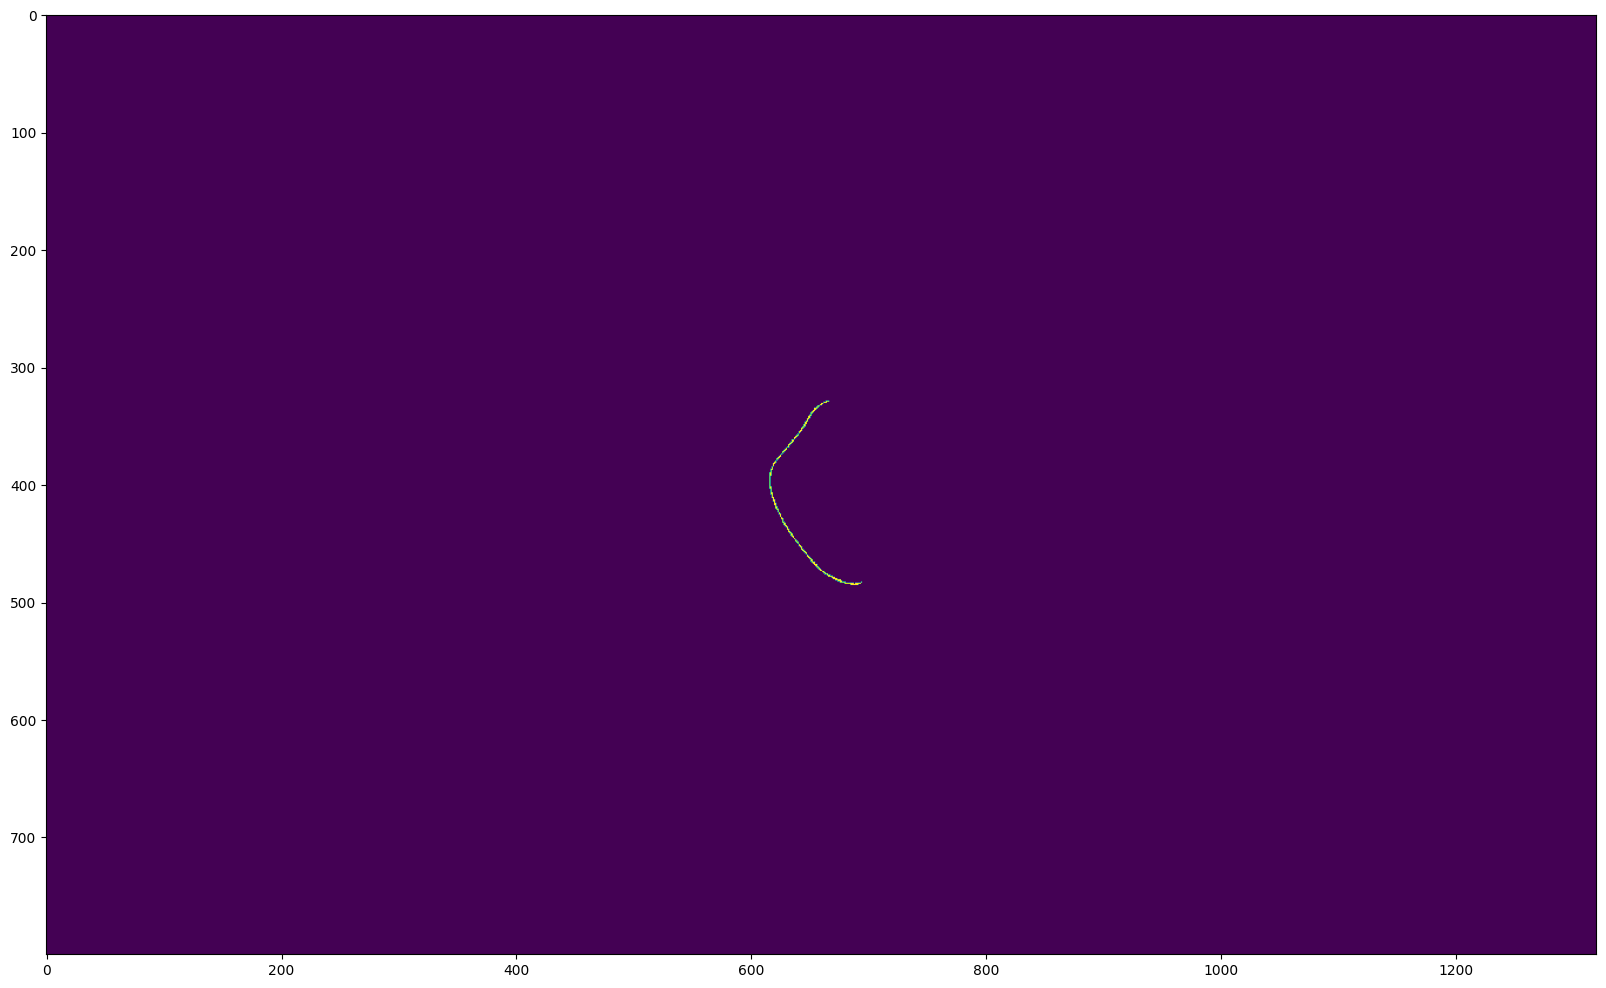

In [6]:

print(rtstructureMask.shape)
mask = np.zeros(rtstructureMask.shape)
plt.figure(figsize=(20, 20)) 
for v in part1mesh.vertices:
    # print(int(v[0]/10),int(v[1]/10),int(v[2]/10))
    mask[int(v[0]/10),int(v[1]/10),int(v[2]/10)]=10
plt.imshow(mask[:,:,360].T)
mask= mask.astype(np.int8)
nrrd.write('../resource/rt/part1.nrrd',mask)


In [3]:
iondata = IONData.IONData()
res,path = iondata.getStructureMask(262)
rtstructureMask,header = nrrd.read(path)
rtstructureMask2 = binary_dilation(rtstructureMask,None,iterations=10)

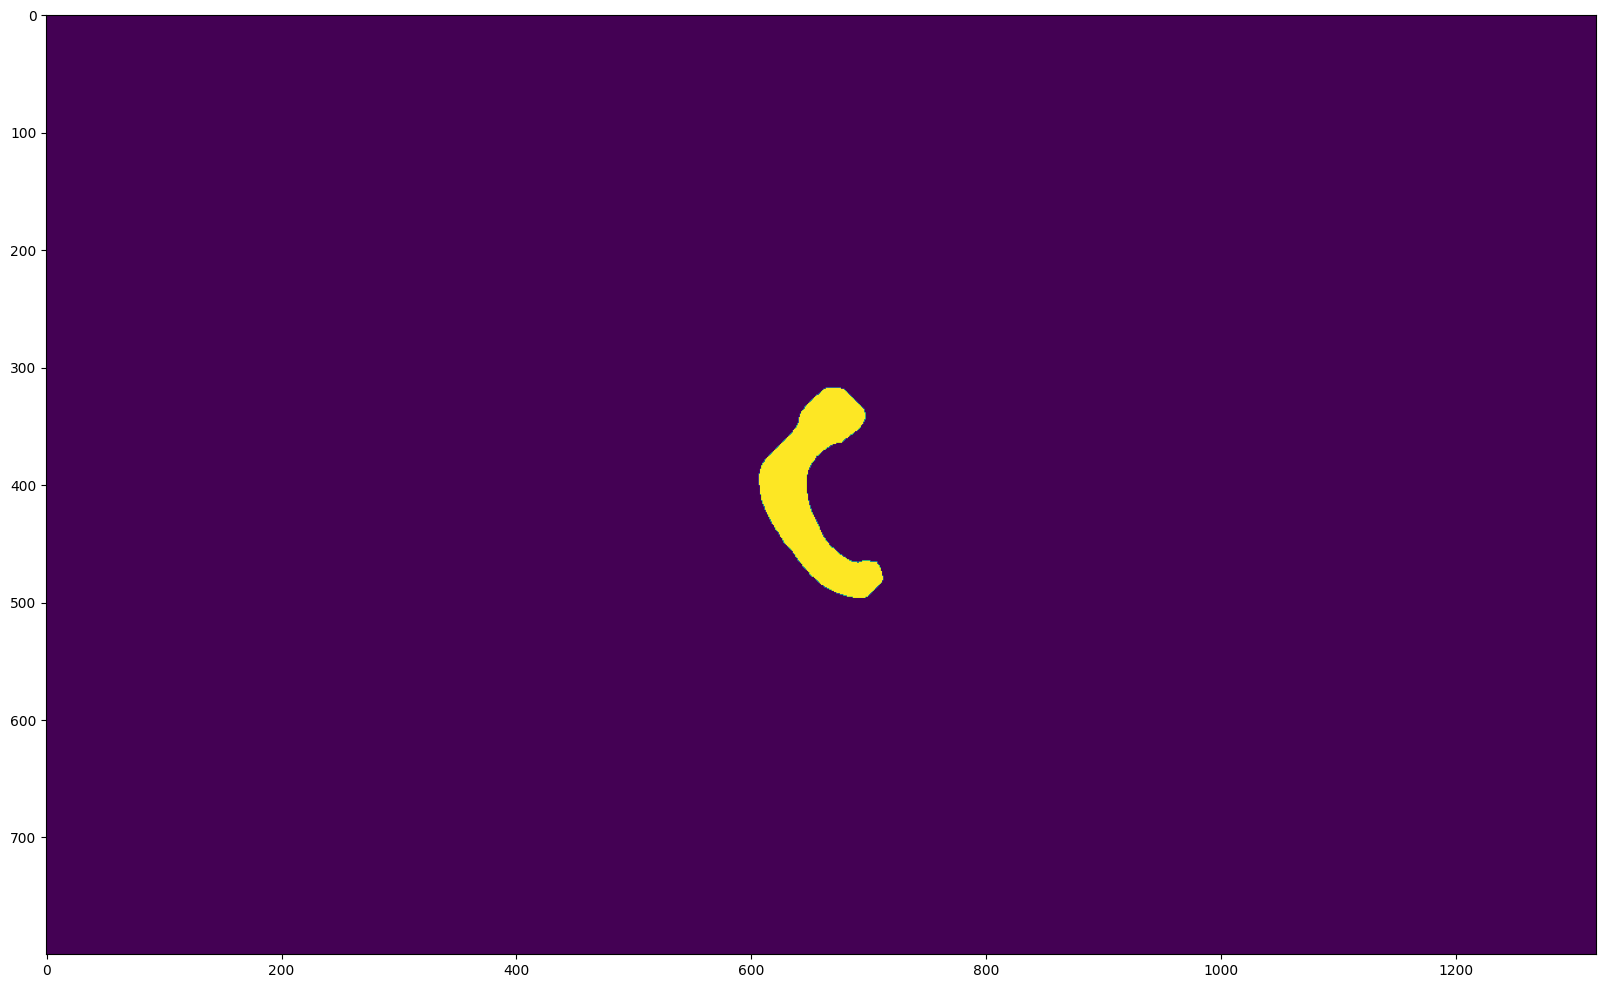

In [4]:
plt.figure(figsize=(20, 20)) 
plt.imshow(rtstructureMask2[:,:,360].T)
rtstructureMask2.dtype
rtstructureMask2=rtstructureMask2.astype(np.int8)
rtstructureMask2 = rtstructureMask2*10
nrrd.write('../resource/rt/rtDilationMask1.nrrd',rtstructureMask2)

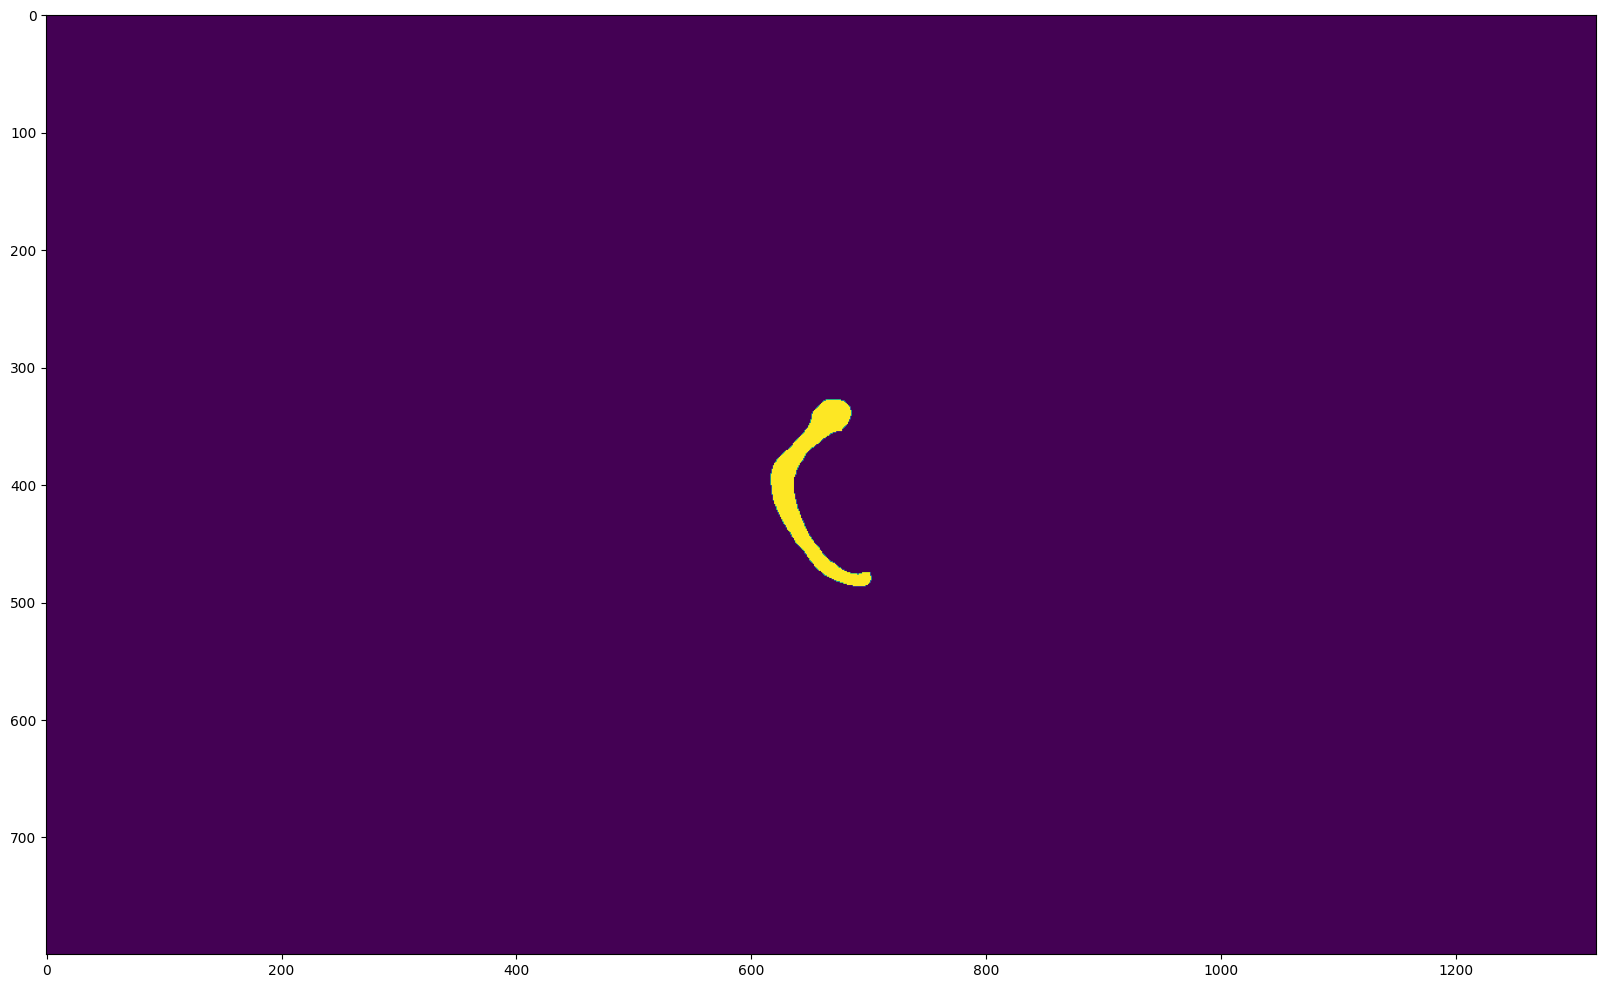

In [6]:
plt.figure(figsize=(20, 20)) 
plt.imshow(rtstructureMask[:,:,360].T)

In [7]:
rtboundaryMask,header = nrrd.read('../resource/rt/rtboundary.nrrd')
rtpart1Mask,header = nrrd.read('../resource/rt/part1.nrrd')
rtpart2Mask,header = nrrd.read('../resource/rt/part2.nrrd')
rtpart1Mask = binary_dilation(rtpart1Mask,None,iterations=2)
rtpart2Mask = binary_dilation(rtpart2Mask,None,iterations=2)

In [58]:
rtpart1Mask.astype(np.int8)
rtpart2Mask.astype(np.int8)
rtpart1Mask = rtpart1Mask*10

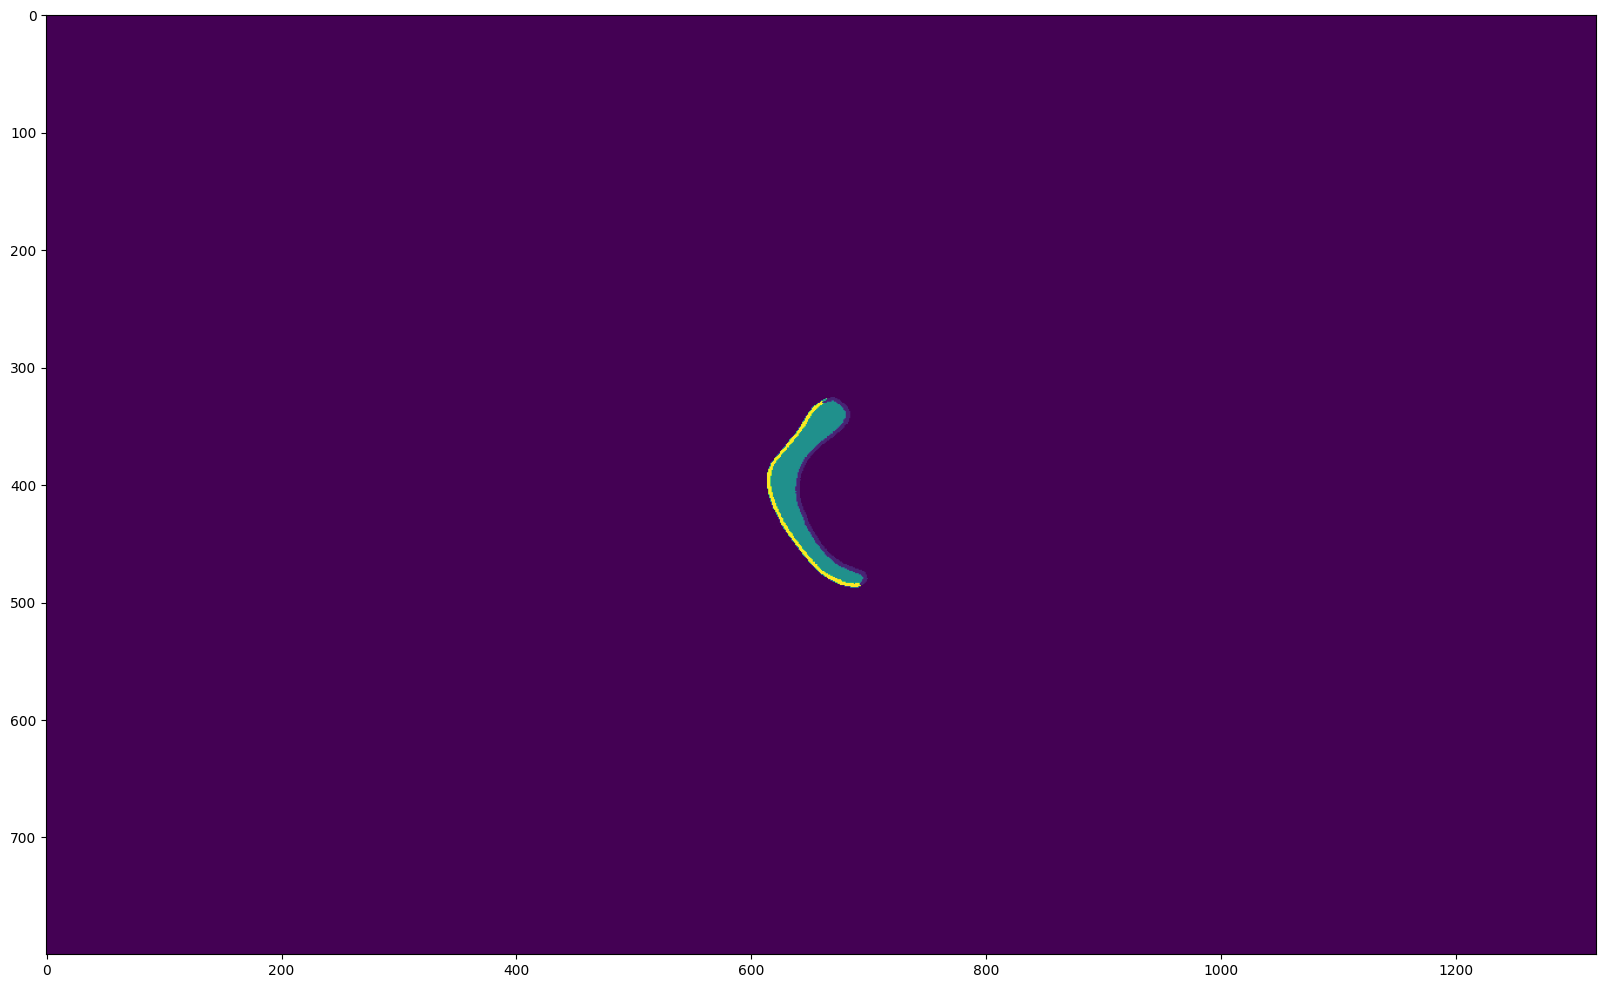

In [67]:
rtpart1Mask[rtpart2Mask==1]=1
rtpart1Mask[rtboundaryMask==2]=5
rtpart1Mask=rtpart1Mask.astype(np.int8)
plt.figure(figsize=(20, 20)) 
plt.imshow(rtpart1Mask[:,:,360].T)

In [69]:
# rtpart1Mask=rtpart1Mask.astype(np.int8)
rtpart1Mask[rtpart1Mask==0]=10
rtpart1Mask[rtpart1Mask==1]=0
rtpart1Mask.dtype
nrrd.write('../resource/rt/test1.nrrd',rtpart1Mask)

In [1]:
rtpart1Mask

NameError: name 'rtpart1Mask' is not defined

In [70]:
rtboundaryMask20,header = nrrd.read('../resource/rt/rtboundary-20.nrrd')
nrrd.write('../resource/rt/rtboundary-20.nrrd',rtboundaryMask20)

In [4]:
rtboundaryMask10,header = nrrd.read('../resource/rt/rtboundary-10.nrrd')


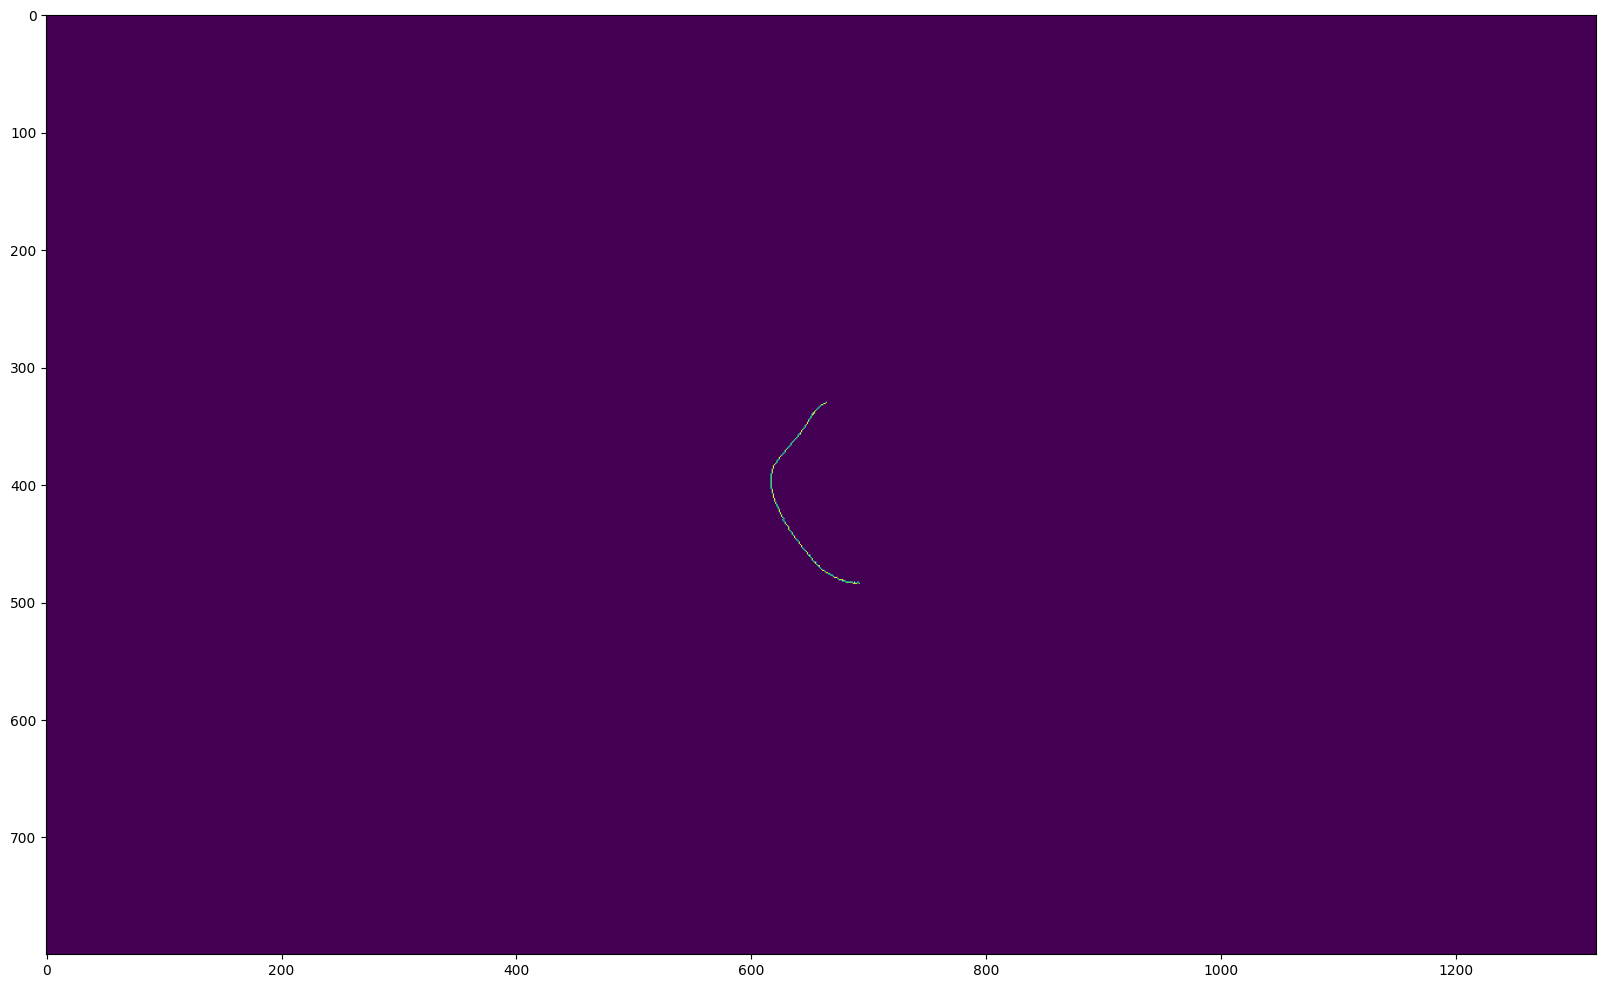

In [16]:

shape = (rtboundaryMask10.shape)
boundary=np.zeros(shape)
for k in range(286,513):
# for k in range(359,360):
    for j in range(325,534):
        for i in range(570,747):
            if rtboundaryMask10[i,j,k]!=5:
                if \
                    rtboundaryMask10[i+1,j,k]==5 or \
                    rtboundaryMask10[i-1,j,k]==5 or \
                    rtboundaryMask10[i,j+1,k]==5 or \
                    rtboundaryMask10[i,j-1,k]==5 or \
                    rtboundaryMask10[i,j,k+1]==5 or \
                    rtboundaryMask10[i,j,k-1]==5:
                    boundary[i,j,k]=rtboundaryMask10[i,j,k]/10
plt.figure(figsize=(20, 20)) 
plt.imshow(boundary[:,:,359].T)

In [19]:
boundary.dtype
boundary=boundary.astype(np.int8)
nrrd.write('../resource/rt/rtboundary10.nrrd',boundary)

In [20]:
shape = (rtboundaryMask10.shape)
rtmask=np.zeros(shape)
rtmask = rtmask.astype(np.int8)
rtmask[rtboundaryMask10==5]=5
nrrd.write('../resource/rt/rtmask.nrrd',rtmask)